<a href="https://colab.research.google.com/github/NAYALLE-GIT/CONCURSO-VII-LP/blob/main/Borrador_concurso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!pip install yfinance pandas plotly

In [29]:

import yfinance as yf
import pandas as pd
import numpy as np
import plotly.express as px

In [30]:
import yfinance as yf
from datetime import date

hoy = date.today().strftime("%Y-%m-%d")

btc = yf.download("BTC-USD", start="2024-01-01", end=hoy, interval="1d")
btc.head()
eth = yf.download("ETH-USD", start="2024-01-01", end=hoy, interval="1d")
eth.head()

/tmp/ipykernel_29707/243354501.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_29707/243354501.py:8: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ETH-USD,ETH-USD,ETH-USD,ETH-USD,ETH-USD
Date,,,,,
2024-01-01,2352.327881,2352.327881,2267.018066,2282.870361,6906765990
2024-01-02,2355.836426,2431.212402,2348.892334,2352.593506,12910543630
2024-01-03,2210.761963,2385.117676,2113.925293,2355.981445,19332933581
2024-01-04,2269.038086,2294.608154,2204.865723,2210.529053,11044564896
2024-01-05,2268.647217,2276.764648,2209.537109,2269.409424,10860953290


In [31]:
fig = px.line(x=btc.index, y=btc['Close']['BTC-USD'], title="BTC-USD 2024-2026")
fig.show()
fig = px.line(x=eth.index, y=eth['Close']['ETH-USD'], title="ETH-USD 2024-2026")
fig.show()

In [32]:
import yfinance as yf
import plotly.express as px
import pandas as pd

# Descarga 2 criptos y compara su rendimiento %
tickers = ["BTC-USD", "ETH-USD"]
data = yf.download(tickers, start="2024-01-01")["Close"]

# Calculate the total percentage change (rendimiento)
rend = (data.iloc[-1] / data.iloc[0] - 1) * 100
print(rend.sort_values(ascending=False))

# Calculate cumulative returns for the plot
daily_returns = data.pct_change().dropna()
# Starting value of 100 for cumulative returns
rendimiento_acumulado_df = (1 + daily_returns).cumprod() * 100

# Convert index to a column for melting
rendimiento_acumulado_df = rendimiento_acumulado_df.reset_index()

# Melt the DataFrame to long format for Plotly Express
rendimiento_acumulado = rendimiento_acumulado_df.melt(id_vars=['Date'], var_name='Cripto', value_name='Valor de $100 invertidos')

fig = px.line(rendimiento_acumulado,
              x='Date',
              y='Valor de $100 invertidos',
              color='Cripto',
              title=" Rendimiento Acumulado — BTC vs ETH (Base 100)")
fig.show()

/tmp/ipykernel_29707/3121966568.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  2 of 2 completed


Ticker
BTC-USD    74.533426
ETH-USD   -10.529910
dtype: float64


In [33]:
import numpy as np
import pandas as pd

btc['retorno'] = btc['Close']['BTC-USD'].pct_change()
eth['retorno'] = eth['Close']['ETH-USD'].pct_change()

vol_anual_btc = btc['retorno'].std() * np.sqrt(252)
print(f"Volatilidad anual BTC: {vol_anual_btc*100:.2f}%")

vol_anual_eth = eth['retorno'].std() * np.sqrt(252)
print(f"Volatilidad anual ETH: {vol_anual_eth*100:.2f}%")

volatilidad = pd.Series({
    'BTC': vol_anual_btc * 100,
    'ETH': vol_anual_eth * 100
})

#GRAFICAS EN BARRA COMPARANDO VOLATILIDAD

fig = px.bar(x=volatilidad.index, y=volatilidad.values,
             title="📊 Volatilidad Anualizada — BTC vs ETH",
             labels={"x": "Cripto", "y": "Volatilidad (%)"},
             color=volatilidad.index)
fig.show()

#GRAFICO EN LINEA RETORNO DIARIO DE BTC-USD

fig_btc_ret = px.line(x=btc.index, y=btc['retorno'], title='Retornos Diarios de BTC-USD')
fig_btc_ret.update_layout(xaxis_title='Fecha', yaxis_title='Retorno Diario')
fig_btc_ret.show()

#GRAFICO EN LINEA RETORNO DIARIO DE ETH-USD

fig_eth_ret = px.line(x=eth.index, y=eth['retorno'], title='Retornos Diarios de ETH-USD')
fig_eth_ret.update_layout(xaxis_title='Fecha', yaxis_title='Retorno Diario')
fig_eth_ret.show()

Volatilidad anual BTC: 40.38%
Volatilidad anual ETH: 58.04%


In [34]:

import plotly.express as px

# Línea de precios
fig = px.line(btc, y=btc['Close']['BTC-USD'], title='Bitcoin 2024')
fig.show()

fig_eth = px.line(eth, y=eth['Close']['ETH-USD'], title='Ethereum 2024')
fig_eth.show()

# Histograma de retornos
fig2 = px.histogram(btc, x='retorno', nbins=50, title='Retornos Diarios BTC')
fig2.show()

fig3 = px.histogram(eth, x='retorno', nbins=50, title='Retornos Diarios ETH')
fig3.show()

<Axes: >

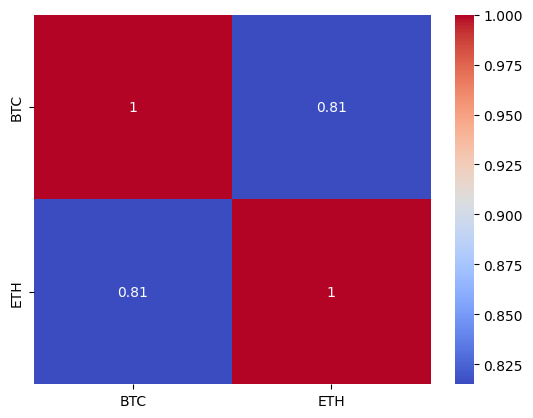

In [35]:
# Calcular correlación
returns = pd.DataFrame({
  'BTC': data['BTC-USD'].pct_change(),
  'ETH': data['ETH-USD'].pct_change(),
  })
corr = returns.corr()

import seaborn as sns
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [36]:
def max_drawdown(serie):
    pico = serie.cummax()
    caida = (serie - pico) / pico * 100
    return caida

    # Calcular drawdown de BTC
btc_drawdown = max_drawdown(btc['Close']['BTC-USD'])

# Calcular drawdown de ETH
eth_drawdown = max_drawdown(eth['Close']['ETH-USD'])

# Ver los resultados
print(f"Máximo Drawdown BTC: {btc_drawdown.min():.2f}%")
print(f"Máximo Drawdown ETH: {eth_drawdown.min():.2f}%")

# Graficar
fig = px.line(x=btc.index, y=btc_drawdown,
              title="Máximo Drawdown — BTC")
fig.show()

fig2 = px.line(x=eth.index, y=eth_drawdown,
               title="Máximo Drawdown — ETH")
fig2.show()

Máximo Drawdown BTC: -49.74%
Máximo Drawdown ETH: -63.79%


In [37]:
retornos_diarios_btc = btc['retorno'].dropna()
dias_negativos_btc = (retornos_diarios_btc < 0).sum() / len(retornos_diarios_btc) * 100
print(f"Porcentaje de días negativos para BTC: {dias_negativos_btc:.2f}%")

retornos_diarios_eth = eth['retorno'].dropna()
dias_negativos_eth = (retornos_diarios_eth < 0).sum() / len(retornos_diarios_eth) * 100
print(f"Porcentaje de días negativos para ETH: {dias_negativos_eth:.2f}%")

Porcentaje de días negativos para BTC: 49.37%
Porcentaje de días negativos para ETH: 48.91%


In [38]:
import plotly.express as px

# ---- PARÁMETROS PERFIL MODERADO ----
UMBRAL_BTC = 0.20  # Salir si BTC cae más del 20%
UMBRAL_ETH = 0.15  # Salir si ETH cae más del 15%
capital = 100

# ---- FUNCIÓN ----
def estrategia_stop_loss(datos, nombre, umbral):
    en_mercado = True
    capital = 100
    historico_capital = []
    precio_pico = datos.iloc[0]

    for i, precio in enumerate(datos):

        # Actualizar pico si el precio sube
        if precio > precio_pico:
            precio_pico = precio

        # Calcular caída desde el pico
        caida = (precio - precio_pico) / precio_pico

        # Regla de entrada y salida
        if en_mercado and caida < -umbral:
            en_mercado = False  # Salir

        elif not en_mercado and caida > -umbral / 2:
            en_mercado = True   # Volver a entrar

        # Calcular capital
        if en_mercado:
            retorno_dia = datos.pct_change().iloc[i] if i > 0 else 0
            capital = capital * (1 + retorno_dia)

        historico_capital.append(capital)

    return historico_capital, capital

# ---- APLICAR A BTC Y ETH ----
hist_btc, cap_btc = estrategia_stop_loss(
    btc['Close']['BTC-USD'], 'BTC', umbral=UMBRAL_BTC)

hist_eth, cap_eth = estrategia_stop_loss(
    eth['Close']['ETH-USD'], 'ETH', umbral=UMBRAL_ETH)

# ---- IMPRIMIR RESULTADOS ----
print(f"BTC (umbral {UMBRAL_BTC*100:.0f}%) — Capital final: ${cap_btc:.2f}")
print(f"ETH (umbral {UMBRAL_ETH*100:.0f}%) — Capital final: ${cap_eth:.2f}")

# ---- GRAFICAR BTC ----
fig = px.line(x=btc.index, y=hist_btc,
              title=f"Estrategia Stop Loss {UMBRAL_BTC*100:.0f}% — BTC")
fig.update_layout(xaxis_title='Fecha', yaxis_title='Capital ($)')
fig.show()

# ---- GRAFICAR ETH ----
fig2 = px.line(x=eth.index, y=hist_eth,
               title=f"Estrategia Stop Loss {UMBRAL_ETH*100:.0f}% — ETH")
fig2.update_layout(xaxis_title='Fecha', yaxis_title='Capital ($)')
fig2.show()

BTC (umbral 20%) — Capital final: $187.02
ETH (umbral 15%) — Capital final: $141.02


In [39]:
import plotly.express as px
import plotly.graph_objects as go

# ---- GRAFICAR BTC CON LÍNEAS DE REFERENCIA ----
fig = go.Figure()

# Línea principal del capital
fig.add_trace(go.Scatter(
    x=btc.index,
    y=hist_btc,
    name='Capital BTC',
    line=dict(color='orange')
))

# Línea de capital inicial
fig.add_hline(y=100,
              line_dash="dash",
              line_color="gray",
              annotation_text="Capital inicial $100")

# Línea de ganancia 10% — señal de volver a entrar
fig.add_hline(y=110,
              line_dash="dot",
              line_color="green",
              annotation_text="Recuperación +10% → Volver a entrar")

# Línea de pérdida 20% — señal de salir
fig.add_hline(y=80,
              line_dash="dot",
              line_color="red",
              annotation_text="Caída -20% → Salir del mercado")

fig.update_layout(
    title="Estrategia Stop Loss 20% — BTC",
    xaxis_title="Fecha",
    yaxis_title="Capital ($)"
)
fig.show()

# ---- GRAFICAR ETH CON LÍNEAS DE REFERENCIA ----
fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=eth.index,
    y=hist_eth,
    name='Capital ETH',
    line=dict(color='blue')
))

fig2.add_hline(y=100,
               line_dash="dash",
               line_color="gray",
               annotation_text="Capital inicial $100")

fig2.add_hline(y=107.5,
               line_dash="dot",
               line_color="green",
               annotation_text="Recuperación +7.5% → Volver a entrar")

fig2.add_hline(y=85,
               line_dash="dot",
               line_color="red",
               annotation_text="Caída -15% → Salir del mercado")

fig2.update_layout(
    title="Estrategia Stop Loss 15% — ETH",
    xaxis_title="Fecha",
    yaxis_title="Capital ($)"
)
fig2.show()

In [40]:
import plotly.graph_objects as go

# ---- BUY & HOLD — comprar y no tocar nada ----
buyhold_btc = (1 + btc['retorno']).cumprod() * 100
buyhold_eth = (1 + eth['retorno']).cumprod() * 100

# ---- IMPRIMIR COMPARACIÓN ----
print("======= BTC =======")
print(f"Estrategia Stop Loss 20%:  ${cap_btc:.2f}")
print(f"Buy & Hold:                ${buyhold_btc.iloc[-1]:.2f}")

print("\n======= ETH =======")
print(f"Estrategia Stop Loss 15%:  ${cap_eth:.2f}")
print(f"Buy & Hold:                ${buyhold_eth.iloc[-1]:.2f}")

# ---- GRAFICAR BTC — Estrategia vs Buy & Hold ----
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=btc.index,
    y=hist_btc,
    name='Estrategia Stop Loss 20%',
    line=dict(color='orange')
))

fig.add_trace(go.Scatter(
    x=btc.index,
    y=buyhold_btc,
    name='Buy & Hold',
    line=dict(color='gray', dash='dash')
))

fig.add_hline(y=100,
              line_dash="dot",
              line_color="white",
              annotation_text="Capital inicial $100")

fig.update_layout(
    title="Backtesting — Estrategia vs Buy & Hold BTC",
    xaxis_title="Fecha",
    yaxis_title="Capital ($)"
)
fig.show()

# ---- GRAFICAR ETH — Estrategia vs Buy & Hold ----
fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=eth.index,
    y=hist_eth,
    name='Estrategia Stop Loss 15%',
    line=dict(color='blue')
))

fig2.add_trace(go.Scatter(
    x=eth.index,
    y=buyhold_eth,
    name='Buy & Hold',
    line=dict(color='gray', dash='dash')
))

fig2.add_hline(y=100,
               line_dash="dot",
               line_color="white",
               annotation_text="Capital inicial $100")

fig2.update_layout(
    title="Backtesting — Estrategia vs Buy & Hold ETH",
    xaxis_title="Fecha",
    yaxis_title="Capital ($)"
)
fig2.show()

======= BTC =======
Estrategia Stop Loss 20%:  $187.02
Buy & Hold:                $173.60

======= ETH =======
Estrategia Stop Loss 15%:  $141.02
Buy & Hold:                $89.95


In [41]:
#PUNTO 9

import plotly.graph_objects as go
import numpy as np

# ---- DEFINIR UMBRAL DE CAÍDA EXTREMA ----
UMBRAL_CAIDA = -0.05  # Días que cayeron más del 5%

# ---- IDENTIFICAR DÍAS DE CAÍDA EXTREMA ----
caidas_btc = btc['retorno'][btc['retorno'] < UMBRAL_CAIDA]
caidas_eth = eth['retorno'][eth['retorno'] < UMBRAL_CAIDA]

# ---- ANÁLISIS DE RECUPERACIÓN ----
def dias_recuperacion(precios, fecha_caida, ventana=30):
    precio_antes = precios.loc[fecha_caida]
    precios_despues = precios.loc[fecha_caida:].iloc[1:ventana]
    recuperado = precios_despues[precios_despues >= precio_antes]
    if len(recuperado) > 0:
        return (recuperado.index[0] - fecha_caida).days
    return None  # No se recuperó en la ventana

# ---- CALCULAR RECUPERACIÓN BTC ----
resultados_btc = []
for fecha in caidas_btc.index:
    dias = dias_recuperacion(btc['Close']['BTC-USD'], fecha)
    resultados_btc.append({
        'fecha': fecha,
        'caida': caidas_btc[fecha] * 100,
        'dias_recuperacion': dias
    })

# ---- CALCULAR RECUPERACIÓN ETH ----
resultados_eth = []
for fecha in caidas_eth.index:
    dias = dias_recuperacion(eth['Close']['ETH-USD'], fecha)
    resultados_eth.append({
        'fecha': fecha,
        'caida': caidas_eth[fecha] * 100,
        'dias_recuperacion': dias
    })

# ---- IMPRIMIR RESUMEN ----
import pandas as pd
df_btc = pd.DataFrame(resultados_btc).dropna()
df_eth = pd.DataFrame(resultados_eth).dropna()

print("======= BTC =======")
print(f"Total caídas extremas:        {len(caidas_btc)} días")
print(f"Promedio de caída:            {caidas_btc.mean()*100:.2f}%")
print(f"Peor caída:                   {caidas_btc.min()*100:.2f}%")
print(f"Promedio días recuperación:   {df_btc['dias_recuperacion'].mean():.1f} días")

print("\n======= ETH =======")
print(f"Total caídas extremas:        {len(caidas_eth)} días")
print(f"Promedio de caída:            {caidas_eth.mean()*100:.2f}%")
print(f"Peor caída:                   {caidas_eth.min()*100:.2f}%")
print(f"Promedio días recuperación:   {df_eth['dias_recuperacion'].mean():.1f} días")

# ---- GRAFICAR CAÍDAS EXTREMAS BTC ----
fig = go.Figure()

# Precio de BTC
fig.add_trace(go.Scatter(
    x=btc.index,
    y=btc['Close']['BTC-USD'],
    name='Precio BTC',
    line=dict(color='orange')
))

# Marcar los días de caída extrema
fig.add_trace(go.Scatter(
    x=caidas_btc.index,
    y=btc['Close']['BTC-USD'].loc[caidas_btc.index],
    mode='markers',
    name='Caída extrema > 5%',
    marker=dict(color='red', size=8, symbol='triangle-down')
))

fig.update_layout(
    title="Caídas Extremas BTC — Días con caída mayor al 5%",
    xaxis_title="Fecha",
    yaxis_title="Precio ($)"
)
fig.show()

# ---- GRAFICAR CAÍDAS EXTREMAS ETH ----
fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=eth.index,
    y=eth['Close']['ETH-USD'],
    name='Precio ETH',
    line=dict(color='blue')
))

fig2.add_trace(go.Scatter(
    x=caidas_eth.index,
    y=eth['Close']['ETH-USD'].loc[caidas_eth.index],
    mode='markers',
    name='Caída extrema > 5%',
    marker=dict(color='red', size=8, symbol='triangle-down')
))

fig2.update_layout(
    title="Caídas Extremas ETH — Días con caída mayor al 5%",
    xaxis_title="Fecha",
    yaxis_title="Precio ($)"
)
fig2.show()

# ---- GRAFICAR TIEMPO DE RECUPERACIÓN ----
fig3 = go.Figure()

fig3.add_trace(go.Bar(
    x=df_btc['fecha'],
    y=df_btc['dias_recuperacion'],
    name='BTC',
    marker_color='orange',
    width=5 * 24 * 60 * 60 * 1000  # 5 días en milisegundos
))

fig3.add_trace(go.Bar(
    x=df_eth['fecha'],
    y=df_eth['dias_recuperacion'],
    name='ETH',
    marker_color='blue',
    width=5 * 24 * 60 * 60 * 1000  # 5 días en milisegundos
))

fig3.update_layout(
    title="Días para Recuperarse después de Caída Extrema — BTC vs ETH",
    xaxis_title="Fecha de caída",
    yaxis_title="Días para recuperarse",
    barmode='group'
)
fig3.show()

======= BTC =======
Total caídas extremas:        24 días
Promedio de caída:            -6.42%
Peor caída:                   -14.13%
Promedio días recuperación:   3.7 días

======= ETH =======
Total caídas extremas:        56 días
Promedio de caída:            -7.30%
Peor caída:                   -15.01%
Promedio días recuperación:   3.6 días


In [45]:
import streamlit as st

In [44]:
!pip install -q streamlit yfinance plotly pandas
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
changed 22 packages in 2s
⠴
⠴3 packages are looking for funding
⠴  run `npm fund` for details
⠴

In [47]:
%%writefile app.py
import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import date
st.set_page_config(
    page_title="Fondo Cripto — Análisis de Inversión",
    page_icon="₿",
    layout="wide"
)

import streamlit as st
import yfinance as yf
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import date

# ---- CONFIGURACIÓN DE LA PÁGINA ----
st.set_page_config(
    page_title="Fondo Cripto — Análisis de Inversión",
    page_icon="₿",
    layout="wide"
)

# ---- ESTILOS ----
st.markdown("""
<style>
    .main { background-color: #0e1117; }
    .metric-card {
        background: linear-gradient(135deg, #1e2130, #2d3250);
        border-radius: 12px;
        padding: 20px;
        text-align: center;
        border: 1px solid #3d4266;
    }
    .metric-value { font-size: 2rem; font-weight: bold; color: #f0b429; }
    .metric-label { font-size: 0.9rem; color: #a0aec0; margin-top: 4px; }
    .section-title {
        font-size: 1.5rem;
        font-weight: bold;
        color: #f0b429;
        border-left: 4px solid #f0b429;
        padding-left: 12px;
        margin: 30px 0 15px 0;
    }
    .explanation-box {
        background: #1a1f2e;
        border-radius: 10px;
        padding: 16px 20px;
        border-left: 3px solid #4a9eff;
        color: #cbd5e0;
        font-size: 0.95rem;
        margin-bottom: 20px;
    }
    .highlight { color: #f0b429; font-weight: bold; }
</style>
""", unsafe_allow_html=True)

# ---- HEADER ----
st.markdown("# ₿ Fondo de Inversión en Criptomonedas")
st.markdown("### Análisis Profesional — Bitcoin & Ethereum")
st.markdown("---")

# ---- INTRO PARA INVERSIONISTAS ----
st.markdown("""
<div class="explanation-box">
💡 <b>¿Qué es este fondo?</b> Un fondo de inversión en criptomonedas es como un portafolio administrado profesionalmente.
En vez de que usted compre y venda solo, nosotros aplicamos <span class="highlight">reglas basadas en datos</span>
para saber cuándo entrar al mercado y cuándo proteger su capital.
</div>
""", unsafe_allow_html=True)

# ---- CARGAR DATOS ----
@st.cache_data
def cargar_datos():
    hoy = date.today().strftime("%Y-%m-%d")
    btc = yf.download("BTC-USD", start="2024-01-01", end=hoy, interval="1d")
    eth = yf.download("ETH-USD", start="2024-01-01", end=hoy, interval="1d")
    btc['retorno'] = btc['Close']['BTC-USD'].pct_change()
    eth['retorno'] = eth['Close']['ETH-USD'].pct_change()
    return btc, eth

with st.spinner("Cargando datos del mercado..."):
    btc, eth = cargar_datos()

# ============================================================
# ÍTEM 1 — PRECIOS HISTÓRICOS
# ============================================================
st.markdown('<div class="section-title">📈 1. Evolución del Precio</div>', unsafe_allow_html=True)
st.markdown("""
<div class="explanation-box">
📌 <b>¿Qué muestra esto?</b> El precio de Bitcoin y Ethereum desde enero 2024 hasta hoy.
Así como usted ve el precio de una casa en el tiempo, aquí ve cómo ha cambiado el valor de cada criptomoneda día a día.
</div>
""", unsafe_allow_html=True)

col1, col2 = st.columns(2)
with col1:
    fig = px.line(x=btc.index, y=btc['Close']['BTC-USD'],
                  title="Bitcoin (BTC) — Precio en USD",
                  color_discrete_sequence=['#f0b429'])
    fig.update_layout(xaxis_title="Fecha", yaxis_title="Precio (USD)",
                      template="plotly_dark")
    st.plotly_chart(fig, use_container_width=True)

with col2:
    fig2 = px.line(x=eth.index, y=eth['Close']['ETH-USD'],
                   title="Ethereum (ETH) — Precio en USD",
                   color_discrete_sequence=['#4a9eff'])
    fig2.update_layout(xaxis_title="Fecha", yaxis_title="Precio (USD)",
                       template="plotly_dark")
    st.plotly_chart(fig2, use_container_width=True)

# ============================================================
# ÍTEM 2 — RETORNOS DIARIOS
# ============================================================
st.markdown('<div class="section-title">📊 2. Movimientos Diarios</div>', unsafe_allow_html=True)
st.markdown("""
<div class="explanation-box">
📌 <b>¿Qué muestra esto?</b> Cuánto sube o baja el precio <b>cada día</b> en porcentaje.
Cuando la línea salta fuerte hacia arriba o abajo, hubo un evento importante ese día.
Entre más tranquila la línea, más estable estuvo el mercado.
</div>
""", unsafe_allow_html=True)

col1, col2 = st.columns(2)
with col1:
    fig = px.line(x=btc.index, y=btc['retorno'],
                  title="Retornos Diarios BTC",
                  color_discrete_sequence=['#f0b429'])
    fig.update_layout(xaxis_title="Fecha", yaxis_title="Retorno Diario",
                      template="plotly_dark")
    st.plotly_chart(fig, use_container_width=True)

with col2:
    fig2 = px.line(x=eth.index, y=eth['retorno'],
                   title="Retornos Diarios ETH",
                   color_discrete_sequence=['#4a9eff'])
    fig2.update_layout(xaxis_title="Fecha", yaxis_title="Retorno Diario",
                       template="plotly_dark")
    st.plotly_chart(fig2, use_container_width=True)

# ============================================================
# ÍTEM 3 — RENDIMIENTO ACUMULADO
# ============================================================
st.markdown('<div class="section-title">💰 3. ¿Cuánto habría ganado con $100?</div>', unsafe_allow_html=True)
st.markdown("""
<div class="explanation-box">
📌 <b>¿Qué muestra esto?</b> Si usted hubiera invertido <b>$100 el 1 de enero de 2024</b>,
esta gráfica muestra cuánto valdría ese dinero cada día hasta hoy.
Es la forma más clara de ver el rendimiento real de cada criptomoneda.
</div>
""", unsafe_allow_html=True)

tickers_data = yf.download(["BTC-USD", "ETH-USD"], start="2024-01-01")["Close"]
daily_returns = tickers_data.pct_change().dropna()
rendimiento_acumulado_df = (1 + daily_returns).cumprod() * 100
rendimiento_acumulado_df = rendimiento_acumulado_df.reset_index()
rendimiento_acumulado = rendimiento_acumulado_df.melt(
    id_vars=['Date'], var_name='Cripto', value_name='Valor de $100 invertidos')

fig = px.line(rendimiento_acumulado, x='Date', y='Valor de $100 invertidos',
              color='Cripto', title="Rendimiento Acumulado — BTC vs ETH (Base $100)",
              color_discrete_map={"BTC-USD": "#f0b429", "ETH-USD": "#4a9eff"})
fig.update_layout(template="plotly_dark")
st.plotly_chart(fig, use_container_width=True)

# ============================================================
# ÍTEM 4 — VOLATILIDAD
# ============================================================
st.markdown('<div class="section-title">⚡ 4. Riesgo — ¿Qué tan impredecible es cada una?</div>', unsafe_allow_html=True)
st.markdown("""
<div class="explanation-box">
📌 <b>¿Qué es la volatilidad?</b> Es una medida de qué tan brusco es el precio.
Alta volatilidad = el precio puede subir o bajar mucho en poco tiempo.
Para comparar: una acción como Apple tiene volatilidad del 25-30%. Las criptos son más volátiles pero con mayor potencial de ganancia.
</div>
""", unsafe_allow_html=True)

retornos_diarios = daily_returns
vol_btc = retornos_diarios['BTC-USD'].std() * np.sqrt(252) * 100
vol_eth = retornos_diarios['ETH-USD'].std() * np.sqrt(252) * 100

col1, col2, col3 = st.columns(3)
with col1:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value">{vol_btc:.1f}%</div>
        <div class="metric-label">Volatilidad Anual BTC</div>
    </div>""", unsafe_allow_html=True)
with col2:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value">{vol_eth:.1f}%</div>
        <div class="metric-label">Volatilidad Anual ETH</div>
    </div>""", unsafe_allow_html=True)
with col3:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value">~27%</div>
        <div class="metric-label">Volatilidad Típica Acciones</div>
    </div>""", unsafe_allow_html=True)

fig = px.bar(x=["BTC-USD", "ETH-USD", "Acciones típicas"],
             y=[vol_btc, vol_eth, 27],
             title="Volatilidad Anualizada — Cripto vs Acciones Tradicionales",
             color=["BTC-USD", "ETH-USD", "Acciones típicas"],
             color_discrete_map={"BTC-USD": "#f0b429", "ETH-USD": "#4a9eff", "Acciones típicas": "#68d391"})
fig.update_layout(template="plotly_dark", showlegend=False,
                  xaxis_title="Activo", yaxis_title="Volatilidad (%)")
st.plotly_chart(fig, use_container_width=True)

# ============================================================
# ÍTEM 5 — MÁXIMO DRAWDOWN
# ============================================================
st.markdown('<div class="section-title">📉 5. Peor Caída Histórica</div>', unsafe_allow_html=True)
st.markdown("""
<div class="explanation-box">
📌 <b>¿Qué es el Drawdown?</b> Es la caída desde el punto más alto hasta el más bajo.
Si Bitcoin llegó a $100,000 y luego bajó a $70,000, el drawdown es -30%.
Es la métrica más honesta del riesgo real — no lo que puede pasar, sino lo que YA pasó.
</div>
""", unsafe_allow_html=True)

def max_drawdown(serie):
    pico = serie.cummax()
    caida = (serie - pico) / pico * 100
    return caida

btc_drawdown = max_drawdown(btc['Close']['BTC-USD'])
eth_drawdown = max_drawdown(eth['Close']['ETH-USD'])

col1, col2 = st.columns(2)
with col1:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value" style="color:#fc8181">{btc_drawdown.min():.1f}%</div>
        <div class="metric-label">Peor caída BTC desde su pico</div>
    </div>""", unsafe_allow_html=True)
with col2:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value" style="color:#fc8181">{eth_drawdown.min():.1f}%</div>
        <div class="metric-label">Peor caída ETH desde su pico</div>
    </div>""", unsafe_allow_html=True)

col1, col2 = st.columns(2)
with col1:
    fig = px.line(x=btc.index, y=btc_drawdown,
                  title="Drawdown BTC — Caída desde el pico",
                  color_discrete_sequence=['#fc8181'])
    fig.update_layout(xaxis_title="Fecha", yaxis_title="Caída (%)",
                      template="plotly_dark")
    st.plotly_chart(fig, use_container_width=True)
with col2:
    fig2 = px.line(x=eth.index, y=eth_drawdown,
                   title="Drawdown ETH — Caída desde el pico",
                   color_discrete_sequence=['#fc8181'])
    fig2.update_layout(xaxis_title="Fecha", yaxis_title="Caída (%)",
                       template="plotly_dark")
    st.plotly_chart(fig2, use_container_width=True)

# ============================================================
# ÍTEM 6 — DÍAS NEGATIVOS
# ============================================================
st.markdown('<div class="section-title">🔴 6. Frecuencia de Pérdidas</div>', unsafe_allow_html=True)
st.markdown("""
<div class="explanation-box">
📌 <b>¿Qué muestra esto?</b> De cada 100 días, cuántos terminaron con el precio más bajo que el día anterior.
Esto es normal en cualquier mercado — lo importante es que los días buenos compensen los malos.
</div>
""", unsafe_allow_html=True)

retornos_diarios_btc = btc['retorno'].dropna()
retornos_diarios_eth = eth['retorno'].dropna()
dias_neg_btc = (retornos_diarios_btc < 0).sum() / len(retornos_diarios_btc) * 100
dias_neg_eth = (retornos_diarios_eth < 0).sum() / len(retornos_diarios_eth) * 100

col1, col2 = st.columns(2)
with col1:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value">{dias_neg_btc:.1f}%</div>
        <div class="metric-label">Días negativos BTC</div>
    </div>""", unsafe_allow_html=True)
with col2:
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value">{dias_neg_eth:.1f}%</div>
        <div class="metric-label">Días negativos ETH</div>
    </div>""", unsafe_allow_html=True)

col1, col2 = st.columns(2)
with col1:
    fig = px.histogram(btc, x='retorno', nbins=50,
                       title='Distribución de Retornos Diarios BTC',
                       color_discrete_sequence=['#f0b429'])
    fig.update_layout(xaxis_title="Retorno Diario", yaxis_title="Cantidad de días",
                      template="plotly_dark")
    st.plotly_chart(fig, use_container_width=True)
with col2:
    fig2 = px.histogram(eth, x='retorno', nbins=50,
                        title='Distribución de Retornos Diarios ETH',
                        color_discrete_sequence=['#4a9eff'])
    fig2.update_layout(xaxis_title="Retorno Diario", yaxis_title="Cantidad de días",
                       template="plotly_dark")
    st.plotly_chart(fig2, use_container_width=True)

# ============================================================
# ÍTEM 7 — ESTRATEGIA STOP LOSS
# ============================================================
st.markdown('<div class="section-title">🛡️ 7. Nuestra Estrategia de Protección</div>', unsafe_allow_html=True)
st.markdown("""
<div class="explanation-box">
📌 <b>¿Cómo protegemos su dinero?</b> Tenemos una regla clara y automática:<br><br>
🔴 <b>Si BTC cae más del 20%</b> desde su punto más alto → Salimos y protegemos el capital<br>
🔴 <b>Si ETH cae más del 15%</b> desde su punto más alto → Salimos y protegemos el capital<br>
🟢 Cuando el precio se recupera → Volvemos a entrar para capturar las ganancias<br><br>
Esto elimina las decisiones emocionales — la regla manda, no el pánico.
</div>
""", unsafe_allow_html=True)

UMBRAL_BTC = 0.20
UMBRAL_ETH = 0.15

def estrategia_stop_loss(datos, umbral):
    en_mercado = True
    capital = 100
    historico_capital = []
    precio_pico = datos.iloc[0]
    for i, precio in enumerate(datos):
        if precio > precio_pico:
            precio_pico = precio
        caida = (precio - precio_pico) / precio_pico
        if en_mercado and caida < -umbral:
            en_mercado = False
        elif not en_mercado and caida > -umbral / 2:
            en_mercado = True
        if en_mercado:
            retorno_dia = datos.pct_change().iloc[i] if i > 0 else 0
            capital = capital * (1 + retorno_dia)
        historico_capital.append(capital)
    return historico_capital, capital

hist_btc, cap_btc = estrategia_stop_loss(btc['Close']['BTC-USD'], UMBRAL_BTC)
hist_eth, cap_eth = estrategia_stop_loss(eth['Close']['ETH-USD'], UMBRAL_ETH)

col1, col2 = st.columns(2)
with col1:
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=btc.index, y=hist_btc,
                             name='Estrategia Stop Loss 20%',
                             line=dict(color='#f0b429')))
    fig.add_hline(y=100, line_dash="dash", line_color="gray",
                  annotation_text="Capital inicial $100")
    fig.add_hline(y=110, line_dash="dot", line_color="green",
                  annotation_text="Volver a entrar +10%")
    fig.add_hline(y=80, line_dash="dot", line_color="red",
                  annotation_text="Salir -20%")
    fig.update_layout(title="Estrategia Stop Loss 20% — BTC",
                      xaxis_title="Fecha", yaxis_title="Capital ($)",
                      template="plotly_dark")
    st.plotly_chart(fig, use_container_width=True)

with col2:
    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=eth.index, y=hist_eth,
                              name='Estrategia Stop Loss 15%',
                              line=dict(color='#4a9eff')))
    fig2.add_hline(y=100, line_dash="dash", line_color="gray",
                   annotation_text="Capital inicial $100")
    fig2.add_hline(y=107.5, line_dash="dot", line_color="green",
                   annotation_text="Volver a entrar +7.5%")
    fig2.add_hline(y=85, line_dash="dot", line_color="red",
                   annotation_text="Salir -15%")
    fig2.update_layout(title="Estrategia Stop Loss 15% — ETH",
                       xaxis_title="Fecha", yaxis_title="Capital ($)",
                       template="plotly_dark")
    st.plotly_chart(fig2, use_container_width=True)

# ============================================================
# ÍTEM 8 — BACKTESTING
# ============================================================
st.markdown('<div class="section-title">⚔️ 8. Estrategia vs No hacer Nada</div>', unsafe_allow_html=True)
st.markdown("""
<div class="explanation-box">
📌 <b>¿Qué es el Backtesting?</b> Es una prueba histórica — tomamos nuestra estrategia y la aplicamos
hacia atrás para ver cómo hubiera funcionado. La línea <b style="color:#f0b429">naranja/azul</b> es nuestra estrategia.
La línea <b style="color:gray">gris punteada</b> es simplemente comprar y no hacer nada.
La que quede más arriba al final ganó más.
</div>
""", unsafe_allow_html=True)

buyhold_btc = (1 + btc['retorno']).cumprod() * 100
buyhold_eth = (1 + eth['retorno']).cumprod() * 100

col1, col2 = st.columns(2)
with col1:
    diferencia_btc = cap_btc - buyhold_btc.iloc[-1]
    color_btc = "#68d391" if diferencia_btc > 0 else "#fc8181"
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value" style="color:{color_btc}">
            {"+" if diferencia_btc > 0 else ""}{diferencia_btc:.2f}$
        </div>
        <div class="metric-label">Ventaja estrategia vs Buy & Hold BTC</div>
    </div>""", unsafe_allow_html=True)

with col2:
    diferencia_eth = cap_eth - buyhold_eth.iloc[-1]
    color_eth = "#68d391" if diferencia_eth > 0 else "#fc8181"
    st.markdown(f"""
    <div class="metric-card">
        <div class="metric-value" style="color:{color_eth}">
            {"+" if diferencia_eth > 0 else ""}{diferencia_eth:.2f}$
        </div>
        <div class="metric-label">Ventaja estrategia vs Buy & Hold ETH</div>
    </div>""", unsafe_allow_html=True)

col1, col2 = st.columns(2)
with col1:
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=btc.index, y=hist_btc,
                             name='Estrategia Stop Loss 20%',
                             line=dict(color='#f0b429')))
    fig.add_trace(go.Scatter(x=btc.index, y=buyhold_btc,
                             name='Buy & Hold',
                             line=dict(color='gray', dash='dash')))
    fig.add_hline(y=100, line_dash="dot", line_color="white",
                  annotation_text="Capital inicial $100")
    fig.update_layout(title="Backtesting BTC — Estrategia vs Buy & Hold",
                      xaxis_title="Fecha", yaxis_title="Capital ($)",
                      template="plotly_dark")
    st.plotly_chart(fig, use_container_width=True)

with col2:
    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=eth.index, y=hist_eth,
                              name='Estrategia Stop Loss 15%',
                              line=dict(color='#4a9eff')))
    fig2.add_trace(go.Scatter(x=eth.index, y=buyhold_eth,
                              name='Buy & Hold',
                              line=dict(color='gray', dash='dash')))
    fig2.add_hline(y=100, line_dash="dot", line_color="white",
                   annotation_text="Capital inicial $100")
    fig2.update_layout(title="Backtesting ETH — Estrategia vs Buy & Hold",
                       xaxis_title="Fecha", yaxis_title="Capital ($)",
                       template="plotly_dark")
    st.plotly_chart(fig2, use_container_width=True)

# ============================================================
# ÍTEM 9 — CAÍDAS EXTREMAS
# ============================================================
st.markdown('<div class="section-title">🌊 9. Caídas Extremas y Recuperación</div>', unsafe_allow_html=True)
st.markdown("""
<div class="explanation-box">
📌 <b>¿Qué muestra esto?</b> Identificamos todos los días donde el precio cayó más del 5% en un solo día
y medimos cuántos días tardó en recuperarse. Los <b style="color:red">triángulos rojos</b> marcan esos días.
En cripto estas caídas son normales — lo importante es saber que el mercado se recupera.
</div>
""", unsafe_allow_html=True)

UMBRAL_CAIDA = -0.05
caidas_btc = btc['retorno'][btc['retorno'] < UMBRAL_CAIDA]
caidas_eth = eth['retorno'][eth['retorno'] < UMBRAL_CAIDA]

def dias_recuperacion(precios, fecha_caida, ventana=30):
    precio_antes = precios.loc[fecha_caida]
    precios_despues = precios.loc[fecha_caida:].iloc[1:ventana]
    recuperado = precios_despues[precios_despues >= precio_antes]
    if len(recuperado) > 0:
        return (recuperado.index[0] - fecha_caida).days
    return None

resultados_btc = []
for fecha in caidas_btc.index:
    dias = dias_recuperacion(btc['Close']['BTC-USD'], fecha)
    resultados_btc.append({'fecha': fecha, 'caida': caidas_btc[fecha] * 100, 'dias_recuperacion': dias})

resultados_eth = []
for fecha in caidas_eth.index:
    dias = dias_recuperacion(eth['Close']['ETH-USD'], fecha)
    resultados_eth.append({'fecha': fecha, 'caida': caidas_eth[fecha] * 100, 'dias_recuperacion': dias})

df_btc_crash = pd.DataFrame(resultados_btc).dropna()
df_eth_crash = pd.DataFrame(resultados_eth).dropna()

col1, col2, col3, col4 = st.columns(4)
with col1:
    st.markdown(f"""<div class="metric-card">
        <div class="metric-value">{len(caidas_btc)}</div>
        <div class="metric-label">Caídas extremas BTC</div>
    </div>""", unsafe_allow_html=True)
with col2:
    st.markdown(f"""<div class="metric-card">
        <div class="metric-value">{df_btc_crash['dias_recuperacion'].mean():.0f} días</div>
        <div class="metric-label">Recuperación promedio BTC</div>
    </div>""", unsafe_allow_html=True)
with col3:
    st.markdown(f"""<div class="metric-card">
        <div class="metric-value">{len(caidas_eth)}</div>
        <div class="metric-label">Caídas extremas ETH</div>
    </div>""", unsafe_allow_html=True)
with col4:
    st.markdown(f"""<div class="metric-card">
        <div class="metric-value">{df_eth_crash['dias_recuperacion'].mean():.0f} días</div>
        <div class="metric-label">Recuperación promedio ETH</div>
    </div>""", unsafe_allow_html=True)

col1, col2 = st.columns(2)
with col1:
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=btc.index, y=btc['Close']['BTC-USD'],
                             name='Precio BTC', line=dict(color='#f0b429')))
    fig.add_trace(go.Scatter(x=caidas_btc.index,
                             y=btc['Close']['BTC-USD'].loc[caidas_btc.index],
                             mode='markers', name='Caída > 5%',
                             marker=dict(color='red', size=8, symbol='triangle-down')))
    fig.update_layout(title="Caídas Extremas BTC",
                      xaxis_title="Fecha", yaxis_title="Precio ($)",
                      template="plotly_dark")
    st.plotly_chart(fig, use_container_width=True)

with col2:
    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=eth.index, y=eth['Close']['ETH-USD'],
                              name='Precio ETH', line=dict(color='#4a9eff')))
    fig2.add_trace(go.Scatter(x=caidas_eth.index,
                              y=eth['Close']['ETH-USD'].loc[caidas_eth.index],
                              mode='markers', name='Caída > 5%',
                              marker=dict(color='red', size=8, symbol='triangle-down')))
    fig2.update_layout(title="Caídas Extremas ETH",
                       xaxis_title="Fecha", yaxis_title="Precio ($)",
                       template="plotly_dark")
    st.plotly_chart(fig2, use_container_width=True)

fig3 = go.Figure()
fig3.add_trace(go.Bar(x=df_btc_crash['fecha'], y=df_btc_crash['dias_recuperacion'],
                      name='BTC', marker_color='#f0b429',
                      width=5 * 24 * 60 * 60 * 1000))
fig3.add_trace(go.Bar(x=df_eth_crash['fecha'], y=df_eth_crash['dias_recuperacion'],
                      name='ETH', marker_color='#4a9eff',
                      width=5 * 24 * 60 * 60 * 1000))
fig3.update_layout(title="Días para Recuperarse después de Caída Extrema",
                   xaxis_title="Fecha de caída", yaxis_title="Días para recuperarse",
                   barmode='group', template="plotly_dark")
st.plotly_chart(fig3, use_container_width=True)

# ============================================================
# CORRELACIÓN
# ============================================================
st.markdown('<div class="section-title">🔗 Correlación entre BTC y ETH</div>', unsafe_allow_html=True)
st.markdown("""
<div class="explanation-box">
📌 <b>¿Qué es la correlación?</b> Mide si dos activos se mueven juntos o por caminos distintos.
Un valor cercano a 1 significa que cuando uno sube el otro también sube.
Esto nos dice qué tan diversificado está el portafolio.
</div>
""", unsafe_allow_html=True)

returns_corr = pd.DataFrame({
    'BTC': tickers_data['BTC-USD'].pct_change(),
    'ETH': tickers_data['ETH-USD'].pct_change(),
})
corr = returns_corr.corr()
fig = px.imshow(corr, text_auto=True,
                color_continuous_scale='RdBu_r',
                title="Correlación BTC vs ETH")
fig.update_layout(template="plotly_dark")
st.plotly_chart(fig, use_container_width=True)

# ============================================================
# CIERRE
# ============================================================
st.markdown("---")
st.markdown("""
<div style="text-align:center; padding: 40px;">
    <h2 style="color:#f0b429">¿Por qué invertir en nuestro fondo?</h2>
    <p style="color:#cbd5e0; font-size:1.1rem; max-width:700px; margin:auto">
    El mercado cripto no va a desaparecer. La pregunta es si van a participar
    de forma <b style="color:#f0b429">inteligente y protegida</b> o van a dejar que las emociones
    tomen las decisiones. Nosotros somos la opción inteligente.
    </p>
</div>
""", unsafe_allow_html=True)

Overwriting app.py


In [48]:
# ver la IP (será la contraseña del túnel) ===
!curl -s https://loca.lt/mytunnelpassword

34.182.173.47

In [ ]:
# lanzar Streamlit en background + abrir túnel ===
!streamlit run app.py &>/content/log.txt &
!sleep 3
!npx --yes localtunnel --port 8501

⠙⠹⠸⠼⠴your url is: https://bitter-waves-love.loca.lt
